In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Read in CSV
df = pd.read_csv('../dataset/online_retail.csv')

# Clean Columns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Cancelled'] = df['InvoiceNo'].str.startswith('C')
df['InvoiceNo'].mask(df['Cancelled'],df['InvoiceNo'].str[1:], inplace=True)

df = df[df.StockCode.str.len() <= 6]
df['StockCode'] = df['StockCode'].str[0:5]
df = df[df.StockCode.str.isnumeric()]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Remove Damage Instances
df_qsum = df[~df.Cancelled].groupby('StockCode')['Quantity'].sum()
problem_instances = df[(df.StockCode.isin(df_qsum[df_qsum < 0].index)) & (df.Quantity < 0) & (~df.Cancelled)].index
df.drop(index=problem_instances,inplace=True)

# Separating Data
df_full = df
df = df[~df.Cancelled]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,TotalPrice
0,536365,85123,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,False,54.08


In [5]:
# Create a Grouped Dataset
products_group = df.groupby('StockCode')[['Quantity','TotalPrice']].sum()
product_details = df.drop_duplicates('StockCode')[['StockCode','Description','UnitPrice']].set_index('StockCode')

products_group = products_group.join(product_details, on='StockCode')

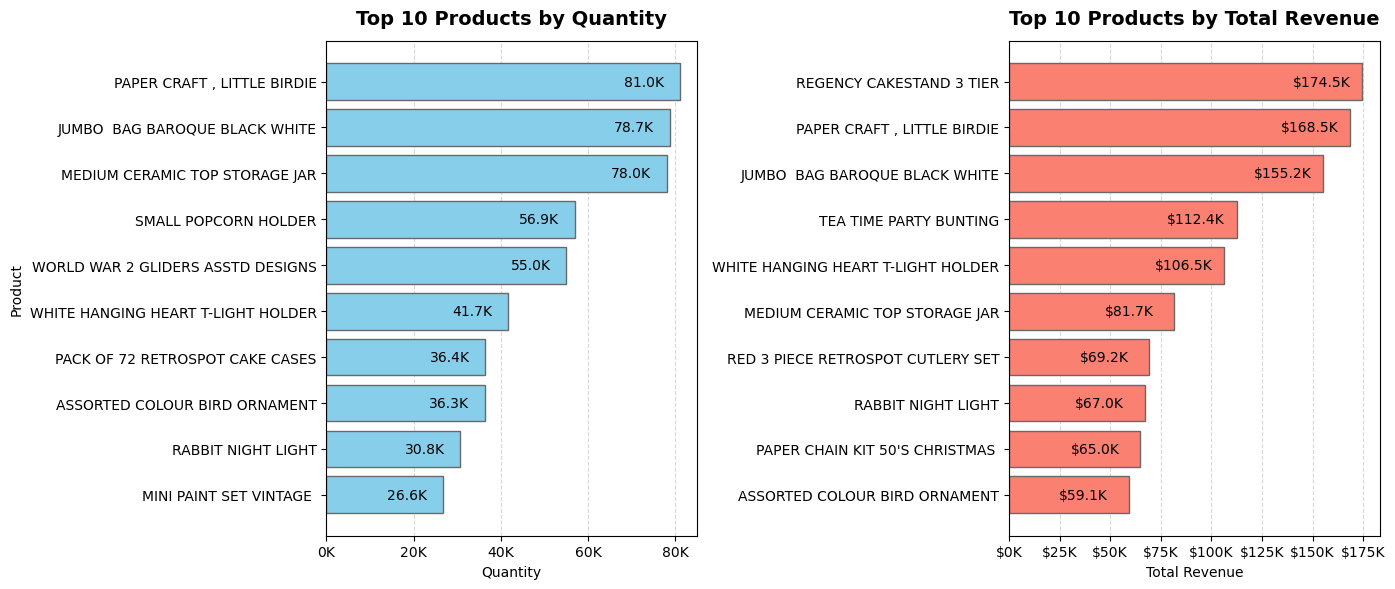

In [189]:
# Setup
top_quantity = products_group.sort_values(by='Quantity',ascending=False).head(10)
top_totalprice = products_group.sort_values(by='TotalPrice',ascending=False).head(10)

fig, ax = plt.subplots(1, 2)
fig.set_size_inches((14, 6))

# Quantity
bars1 = ax[0].barh(top_quantity['Description'], top_quantity['Quantity'], color='skyblue', edgecolor='dimgrey')
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Products by Quantity', fontsize=14, weight='bold', pad=12)
ax[0].set_xlabel('Quantity')
ax[0].set_ylabel('Product')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
labels1 = [f'{x/1000:.1f}K' for x in top_quantity['Quantity']]
ax[0].bar_label(bars1, labels=labels1, padding=-40)
ax[0].grid(axis='x', linestyle='--', alpha=0.5)
ax[0].set_axisbelow(True)

# Total Price
bars2 = ax[1].barh(top_totalprice['Description'], top_totalprice['TotalPrice'], color='salmon', edgecolor='dimgrey')
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Products by Total Revenue', fontsize=14, weight='bold', pad=12)
ax[1].set_xlabel('Total Revenue')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
labels2 = [f'${x/1000:.1f}K' for x in top_totalprice['TotalPrice']]
ax[1].bar_label(bars2, labels=labels2, padding=-50)
ax[1].grid(axis='x', linestyle='--', alpha=0.5)
ax[1].set_axisbelow(True)

# Finish
plt.tight_layout()

C:\Users\Edwar\AppData\Local\Temp\ipykernel_18416\3462236887.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_grouped = products_group.groupby('PriceBand')['TotalPrice'].sum()


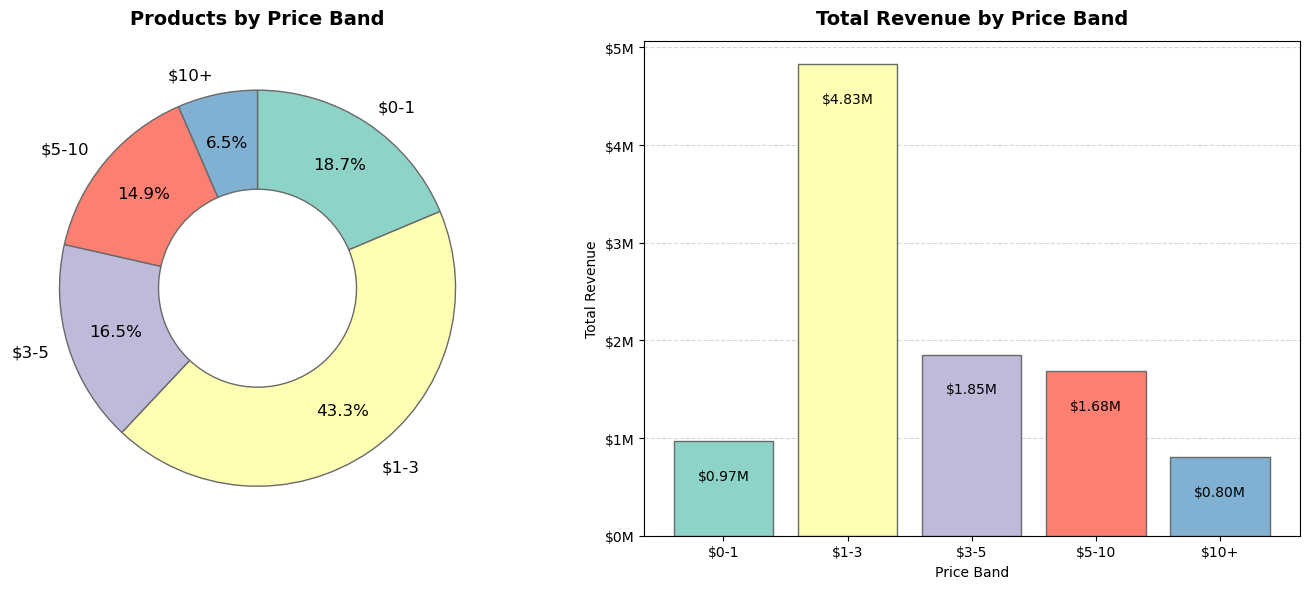

In [ ]:
products_group['PriceBand'] = pd.cut(
    products_group['UnitPrice'], 
    bins=[0,1,3,5,10,float('inf')], 
    labels=['$0-1', '$1-3', '$3-5', '$5-10', '$10+']
)
price_counts = products_group['PriceBand'].value_counts().sort_index()
price_grouped = products_group.groupby('PriceBand')['TotalPrice'].sum()

fig, ax = plt.subplots(1, 2)
fig.set_size_inches((14, 6))

# Pie Chart
colors = plt.cm.Set3(range(len(price_counts)))
ax[0].pie(
    x=price_counts,
    labels=price_counts.index,
    startangle=90,
    counterclock=False,
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'dimgrey', 'width': 0.5},
    textprops={'size':'large'}
)
ax[0].set_title('Products by Price Band', weight='bold', fontsize=14,pad=12)

# Bar Chart
bars3 = ax[1].bar(height=price_grouped, x=price_grouped.index, color=colors, edgecolor='dimgrey')
ax[1].set_title('Total Revenue by Price Band', weight='bold', fontsize=14,pad=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)
ax[1].set_axisbelow(True)
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000000:.0f}M'))
labels3 = [f'${x/1000000:.2f}M' for x in price_grouped]
ax[1].bar_label(bars3, labels=labels3, padding=-30)
ax[1].set_ylabel('Total Revenue')
ax[1].set_xlabel('Price Band')

# Finish
plt.tight_layout()